<a href="https://colab.research.google.com/github/C0utinhoxx/CHECKPOINT_02_SERS_1CCX_2SEM/blob/main/Avaliacao_APIs_Energia_Renovavel_ML_COMPLETA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [37]:
import json
import urllib.parse
import urllib.request
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

pd.set_option("display.max_columns", None)


A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [38]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [39]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [40]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [41]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [42]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

## 3. Análise exploratória — Classificação

Agora será realizada a parte de aprendizado de máquina da tarefa de classificação.

O objetivo é prever se um empreendimento pertence à classe **Solar**, **Eólica** ou **Hidráulica** utilizando somente:

- `potencia_kw`
- `latitude`
- `longitude`

A variável alvo é `fonte`.

Serão comparados três classificadores:

1. Regressão Logística
2. k-Nearest Neighbors (kNN)
3. Árvore de Decisão


In [43]:
df_classificacao = pd.read_csv("aneel_classificacao_orange.csv")

print("Dimensão do conjunto de dados:")
print(df_classificacao.shape)

print("\nPrimeiros registros:")
display(df_classificacao.head())

print("\nTipos das colunas:")
print(df_classificacao.dtypes)

print("\nValores ausentes por coluna:")
print(df_classificacao.isnull().sum())


Dimensão do conjunto de dados:
(3876, 4)

Primeiros registros:


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar



Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64


In [44]:
print("Estatísticas das variáveis numéricas:")
display(
    df_classificacao[
        ["potencia_kw", "latitude", "longitude"]
    ].describe()
)

print("\nQuantidade de registros por fonte:")
distribuicao_classes = df_classificacao["fonte"].value_counts()
display(distribuicao_classes)


Estatísticas das variáveis numéricas:


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000



Quantidade de registros por fonte:


,count
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


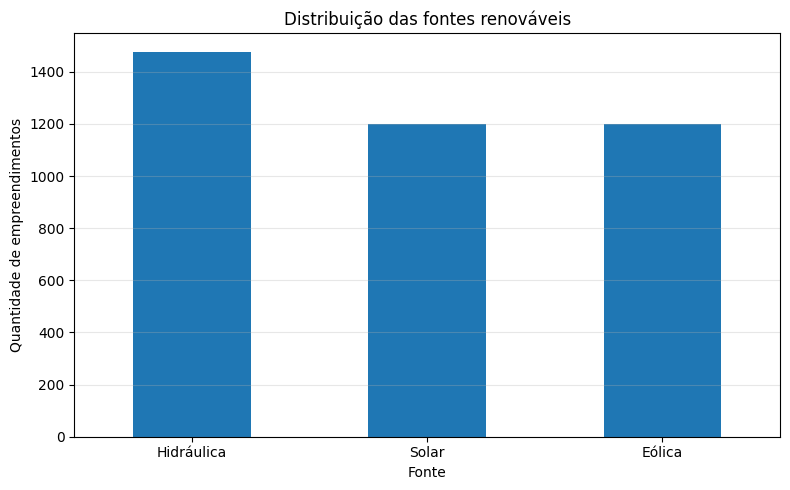

In [45]:
plt.figure(figsize=(8, 5))
distribuicao_classes.plot(kind="bar")
plt.title("Distribuição das fontes renováveis")
plt.xlabel("Fonte")
plt.ylabel("Quantidade de empreendimentos")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretação da distribuição

O gráfico mostra a quantidade de exemplos disponíveis para cada classe no conjunto consultado.

Essas quantidades representam somente os registros retornados e preparados para esta atividade e **não devem ser interpretadas como a participação real das fontes na matriz energética brasileira**.


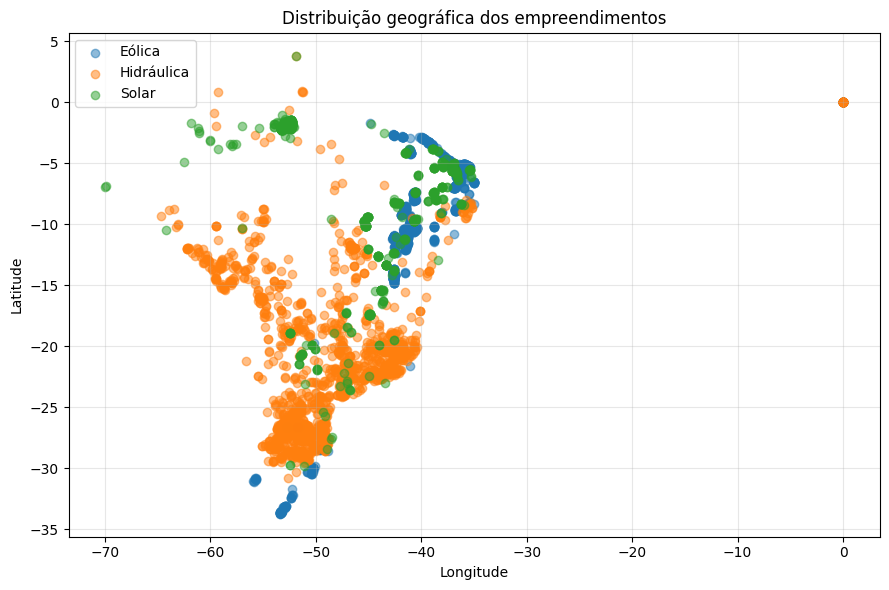

In [46]:
plt.figure(figsize=(9, 6))

for fonte in sorted(df_classificacao["fonte"].unique()):
    dados_fonte = df_classificacao[df_classificacao["fonte"] == fonte]

    plt.scatter(
        dados_fonte["longitude"],
        dados_fonte["latitude"],
        label=fonte,
        alpha=0.5
    )

plt.title("Distribuição geográfica dos empreendimentos")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Definição de X e y

As variáveis de entrada (`X`) serão potência, latitude e longitude.  
A variável alvo (`y`) será a fonte renovável.

Não são utilizados nome, código, sigla original ou qualquer outra coluna que revele diretamente a resposta.


In [47]:
X = df_classificacao[
    ["potencia_kw", "latitude", "longitude"]
]

y = df_classificacao["fonte"]

print("X:")
display(X.head())

print("\ny:")
display(y.head())


X:


,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000



y:


,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


## 5. Divisão estratificada de treino e teste

Será utilizada a divisão de **80% para treinamento e 20% para teste**.

O parâmetro `stratify=y` preserva aproximadamente a proporção das três classes nos dois conjuntos.  
Também será utilizada a semente `random_state=42` para permitir a reprodução da mesma divisão.


In [48]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Quantidade de registros de treino:", len(X_treino))
print("Quantidade de registros de teste:", len(X_teste))

print("\nDistribuição proporcional no treino:")
display(y_treino.value_counts(normalize=True).round(4))

print("\nDistribuição proporcional no teste:")
display(y_teste.value_counts(normalize=True).round(4))


Quantidade de registros de treino: 3100
Quantidade de registros de teste: 776

Distribuição proporcional no treino:


,proportion
fonte,
Hidráulica,0.3806
Solar,0.3097
Eólica,0.3097



Distribuição proporcional no teste:


,proportion
fonte,
Hidráulica,0.3814
Solar,0.3093
Eólica,0.3093


## 6. Modelos de classificação

Serão comparados os três algoritmos utilizando exatamente os mesmos conjuntos de treino e teste.

A Regressão Logística e o kNN utilizam padronização com `StandardScaler` dentro de um `Pipeline`.  
Dessa forma, o ajuste da escala é aprendido somente com os dados de treinamento.


In [49]:
modelos_classificacao = {
    "Regressão Logística": Pipeline([
        ("padronizacao", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "kNN": Pipeline([
        ("padronizacao", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Árvore de Decisão": DecisionTreeClassifier(
        random_state=42,
        min_samples_leaf=2
    )
}

modelos_classificacao


{'Regressão Logística': Pipeline(steps=[('padronizacao', StandardScaler()),
                 ('modelo', LogisticRegression(max_iter=2000, random_state=42))]),
 'kNN': Pipeline(steps=[('padronizacao', StandardScaler()),
                 ('modelo', KNeighborsClassifier())]),
 'Árvore de Decisão': DecisionTreeClassifier(min_samples_leaf=2, random_state=42)}

## 7. Treinamento e comparação

Para Precision, Recall e F1 será utilizada a média **macro**.

A média macro calcula a métrica separadamente para cada classe e depois tira a média, dando o mesmo peso para Solar, Eólica e Hidráulica.


In [50]:
resultados_classificacao = []
previsoes_classificacao = {}

for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_treino, y_treino)
    previsoes = modelo.predict(X_teste)

    previsoes_classificacao[nome] = previsoes

    resultados_classificacao.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, previsoes),
        "Precision Macro": precision_score(
            y_teste, previsoes, average="macro", zero_division=0
        ),
        "Recall Macro": recall_score(
            y_teste, previsoes, average="macro", zero_division=0
        ),
        "F1 Macro": f1_score(
            y_teste, previsoes, average="macro", zero_division=0
        )
    })

resultado_classificacao_df = pd.DataFrame(resultados_classificacao)

resultado_classificacao_df = resultado_classificacao_df.sort_values(
    by="F1 Macro",
    ascending=False
).reset_index(drop=True)

display(resultado_classificacao_df.round(4))


,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,kNN,0.9652,0.9663,0.9636,0.9648
1,Árvore de Decisão,0.9575,0.9575,0.9568,0.9571
2,Regressão Logística,0.8247,0.8282,0.8214,0.8197


## 8. Matrizes de confusão



Modelo: Regressão Logística


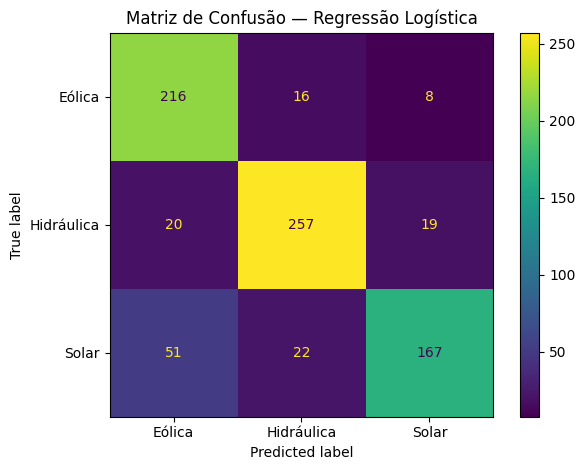


Modelo: kNN


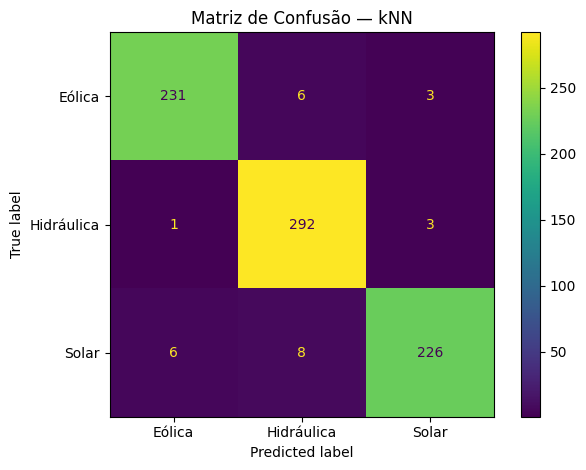


Modelo: Árvore de Decisão


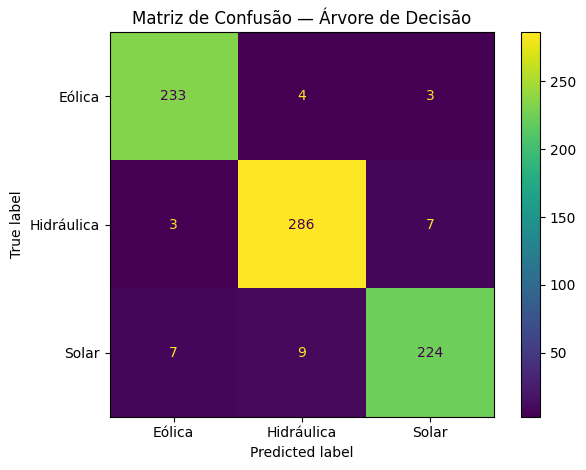

In [51]:
classes = sorted(y_teste.unique())

for nome, previsoes in previsoes_classificacao.items():
    print("\nModelo:", nome)

    ConfusionMatrixDisplay.from_predictions(
        y_teste,
        previsoes,
        labels=classes
    )

    plt.title(f"Matriz de Confusão — {nome}")
    plt.tight_layout()
    plt.show()


## 9. Melhor resultado e classes mais confundidas

Para facilitar a interpretação, o código abaixo seleciona o modelo com maior **F1 Macro** e identifica qual foi a confusão mais frequente entre classes diferentes.


In [52]:
melhor_modelo_classificacao = resultado_classificacao_df.iloc[0]["Modelo"]
melhor_f1 = resultado_classificacao_df.iloc[0]["F1 Macro"]
melhor_accuracy = resultado_classificacao_df.iloc[0]["Accuracy"]

melhores_previsoes = previsoes_classificacao[melhor_modelo_classificacao]

print("Melhor classificador pelo F1 Macro:")
print(melhor_modelo_classificacao)

print("\nF1 Macro:", round(melhor_f1, 4))
print("Accuracy:", round(melhor_accuracy, 4))

print("\nRelatório detalhado:")
print(
    classification_report(
        y_teste,
        melhores_previsoes,
        zero_division=0
    )
)


Melhor classificador pelo F1 Macro:
kNN

F1 Macro: 0.9648
Accuracy: 0.9652

Relatório detalhado:
              precision    recall  f1-score   support

      Eólica       0.97      0.96      0.97       240
  Hidráulica       0.95      0.99      0.97       296
       Solar       0.97      0.94      0.96       240

    accuracy                           0.97       776
   macro avg       0.97      0.96      0.96       776
weighted avg       0.97      0.97      0.97       776



In [53]:
matriz = confusion_matrix(
    y_teste,
    melhores_previsoes,
    labels=classes
)

matriz_sem_diagonal = matriz.copy()
np.fill_diagonal(matriz_sem_diagonal, 0)

linha, coluna = np.unravel_index(
    matriz_sem_diagonal.argmax(),
    matriz_sem_diagonal.shape
)

classe_real = classes[linha]
classe_prevista = classes[coluna]
quantidade_erros = int(matriz_sem_diagonal[linha, coluna])

print(
    f"A confusão mais frequente do melhor modelo ocorreu quando "
    f"{classe_real} foi classificada como {classe_prevista}."
)
print(f"Quantidade de casos: {quantidade_erros}")


A confusão mais frequente do melhor modelo ocorreu quando Solar foi classificada como Hidráulica.
Quantidade de casos: 8


### Conclusão — Classificação

Foram comparados **Regressão Logística, kNN e Árvore de Decisão**, todos utilizando a mesma divisão de treino e teste.

As métricas multiclasses Precision, Recall e F1 foram calculadas com média `macro`, atribuindo o mesmo peso às três classes.

Os resultados permitem verificar até que ponto potência e localização geográfica ajudam a distinguir Solar, Eólica e Hidráulica. Entretanto, essas três características não são suficientes para identificar perfeitamente a fonte: empreendimentos de fontes diferentes podem apresentar potências semelhantes e também podem estar localizados em regiões próximas.

A matriz de confusão deve ser utilizada junto com a tabela de métricas para identificar quais classes o modelo mais confundiu.

Em uma aplicação real, outras características poderiam melhorar o desempenho, desde que não fossem variáveis que entregassem diretamente a classe desejada.


# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [54]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [55]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [56]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [57]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## 5. Análise exploratória — Regressão

Agora será realizada a parte de aprendizado de máquina da tarefa de regressão.

O objetivo é estimar `radiacao_w_m2` utilizando:

- `temperatura_c`
- `umidade_pct`
- `nuvens_pct`
- `vento_kmh`
- `hora`

`data_hora` será utilizada para preservar a ordem cronológica, mas não será usada como entrada direta do modelo.

Serão comparados três algoritmos:

1. Regressão Linear
2. kNN Regressor
3. Árvore de Decisão para Regressão


In [58]:
df_regressao = pd.read_csv("meteo_regressao_orange.csv")

df_regressao["data_hora"] = pd.to_datetime(
    df_regressao["data_hora"]
)

df_regressao = df_regressao.sort_values(
    "data_hora"
).reset_index(drop=True)

print("Dimensão do conjunto de dados:")
print(df_regressao.shape)

print("\nPrimeiros registros:")
display(df_regressao.head())

print("\nÚltimos registros:")
display(df_regressao.tail())

print("\nValores ausentes:")
print(df_regressao.isnull().sum())


Dimensão do conjunto de dados:
(1001, 7)

Primeiros registros:


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0



Últimos registros:


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
996,2025-06-30 13:00:00,26.9,56,100,18.5,13,399.0
997,2025-06-30 14:00:00,26.8,56,81,16.8,14,252.0
998,2025-06-30 15:00:00,27.3,55,82,15.9,15,286.0
999,2025-06-30 16:00:00,27.2,54,100,15.8,16,151.0
1000,2025-06-30 17:00:00,26.8,56,96,12.8,17,49.0



Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


In [59]:
print("Estatísticas das variáveis:")
display(
    df_regressao[
        [
            "temperatura_c",
            "umidade_pct",
            "nuvens_pct",
            "vento_kmh",
            "hora",
            "radiacao_w_m2"
        ]
    ].describe()
)


Estatísticas das variáveis:


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


## 6. Visualizações dos dados

Primeiro será observada a relação entre a hora do dia e a radiação solar média.


,radiacao_w_m2
hora,
7,83.395604
8,260.494505
9,434.824176
10,605.340659
11,693.428571
12,727.912088
13,721.890110
14,654.879121
15,523.318681


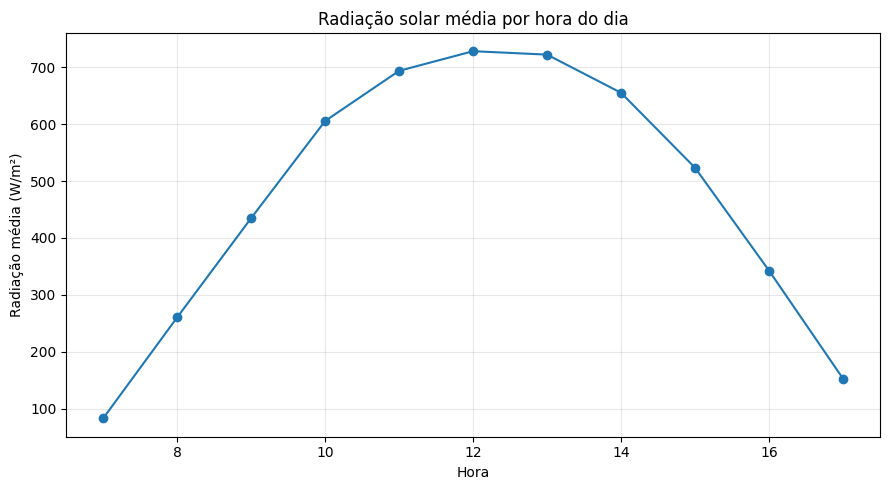

In [60]:
radiacao_por_hora = (
    df_regressao
    .groupby("hora")["radiacao_w_m2"]
    .mean()
)

display(radiacao_por_hora)

plt.figure(figsize=(9, 5))
plt.plot(
    radiacao_por_hora.index,
    radiacao_por_hora.values,
    marker="o"
)

plt.title("Radiação solar média por hora do dia")
plt.xlabel("Hora")
plt.ylabel("Radiação média (W/m²)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


A hora é uma variável importante porque a disponibilidade de radiação solar varia naturalmente ao longo do dia.  
A tendência esperada é de crescimento durante a manhã, valores maiores próximos ao meio do dia e redução durante a tarde.


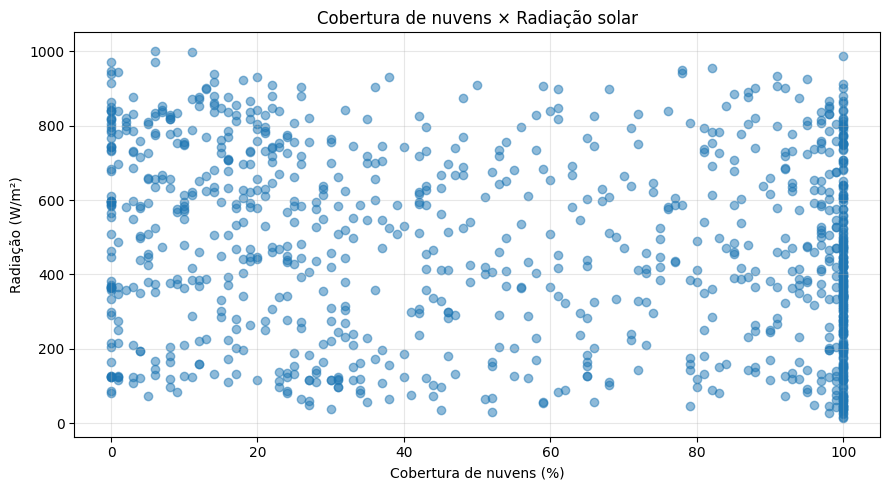

In [61]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df_regressao["nuvens_pct"],
    df_regressao["radiacao_w_m2"],
    alpha=0.5
)

plt.title("Cobertura de nuvens × Radiação solar")
plt.xlabel("Cobertura de nuvens (%)")
plt.ylabel("Radiação (W/m²)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Definição de X e y

A variável `radiacao_w_m2` é o alvo e **não será utilizada para criar nenhuma entrada do mesmo registro**.


In [62]:
variaveis_regressao = [
    "temperatura_c",
    "umidade_pct",
    "nuvens_pct",
    "vento_kmh",
    "hora"
]

X_regressao = df_regressao[variaveis_regressao]
y_regressao = df_regressao["radiacao_w_m2"]

print("X:")
display(X_regressao.head())

print("\ny:")
display(y_regressao.head())


X:


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11



y:


,radiacao_w_m2
0,116.0
1,269.0
2,529.0
3,797.0
4,880.0


## 8. Divisão temporal de treino e teste

Os registros não serão embaralhados.

As primeiras **80% das horas** serão usadas para treinamento e as **20% finais** para teste.  
Esse procedimento preserva a ordem temporal dos dados.


In [63]:
corte = int(len(df_regressao) * 0.80)

X_treino_regressao = X_regressao.iloc[:corte]
X_teste_regressao = X_regressao.iloc[corte:]

y_treino_regressao = y_regressao.iloc[:corte]
y_teste_regressao = y_regressao.iloc[corte:]

datas_teste = df_regressao["data_hora"].iloc[corte:]

print("Total de registros:", len(df_regressao))
print("Registros de treinamento:", len(X_treino_regressao))
print("Registros de teste:", len(X_teste_regressao))

print("\nPeríodo do treinamento:")
print(
    df_regressao.iloc[0]["data_hora"],
    "até",
    df_regressao.iloc[corte - 1]["data_hora"]
)

print("\nPeríodo do teste:")
print(
    df_regressao.iloc[corte]["data_hora"],
    "até",
    df_regressao.iloc[-1]["data_hora"]
)


Total de registros: 1001
Registros de treinamento: 800
Registros de teste: 201

Período do treinamento:
2025-04-01 07:00:00 até 2025-06-12 14:00:00

Período do teste:
2025-06-12 15:00:00 até 2025-06-30 17:00:00


## 9. Modelos de regressão

Os três modelos abaixo utilizarão exatamente a mesma divisão temporal.

O kNN Regressor utiliza padronização em um `Pipeline`, garantindo que a escala seja ajustada somente a partir do conjunto de treinamento.


In [64]:
modelos_regressao = {
    "Regressão Linear": LinearRegression(),

    "kNN Regressor": Pipeline([
        ("padronizacao", StandardScaler()),
        ("modelo", KNeighborsRegressor(n_neighbors=5))
    ]),

    "Árvore de Decisão": DecisionTreeRegressor(
        random_state=42,
        min_samples_leaf=2
    )
}

modelos_regressao


{'Regressão Linear': LinearRegression(),
 'kNN Regressor': Pipeline(steps=[('padronizacao', StandardScaler()),
                 ('modelo', KNeighborsRegressor())]),
 'Árvore de Decisão': DecisionTreeRegressor(min_samples_leaf=2, random_state=42)}

## 10. Treinamento e comparação

Serão comparadas as seguintes métricas:

- **MAE** — erro absoluto médio, em W/m²;
- **MSE** — erro quadrático médio, em (W/m²)²;
- **R²** — coeficiente de determinação.


In [65]:
resultados_regressao = []
previsoes_regressao = {}

for nome, modelo in modelos_regressao.items():
    modelo.fit(
        X_treino_regressao,
        y_treino_regressao
    )

    previsoes = modelo.predict(
        X_teste_regressao
    )

    previsoes_regressao[nome] = previsoes

    resultados_regressao.append({
        "Modelo": nome,
        "MAE": mean_absolute_error(
            y_teste_regressao,
            previsoes
        ),
        "MSE": mean_squared_error(
            y_teste_regressao,
            previsoes
        ),
        "R²": r2_score(
            y_teste_regressao,
            previsoes
        )
    })

resultado_regressao_df = pd.DataFrame(resultados_regressao)

resultado_regressao_df = resultado_regressao_df.sort_values(
    by="MAE",
    ascending=True
).reset_index(drop=True)

display(resultado_regressao_df.round(4))


,Modelo,MAE,MSE,R²
0,kNN Regressor,68.2706,7607.9614,0.8378
1,Árvore de Decisão,84.4992,13880.2562,0.7042
2,Regressão Linear,145.2049,30034.2011,0.3598


## 11. Melhor regressor


In [66]:
melhor_modelo_regressao = resultado_regressao_df.iloc[0]["Modelo"]
melhor_mae = resultado_regressao_df.iloc[0]["MAE"]
melhor_mse = resultado_regressao_df.iloc[0]["MSE"]
melhor_r2 = resultado_regressao_df.iloc[0]["R²"]

melhores_previsoes_regressao = previsoes_regressao[
    melhor_modelo_regressao
]

print("Melhor modelo pelo menor MAE:")
print(melhor_modelo_regressao)

print("\nMAE:", round(melhor_mae, 2), "W/m²")
print("MSE:", round(melhor_mse, 2), "(W/m²)²")
print("R²:", round(melhor_r2, 4))


Melhor modelo pelo menor MAE:
kNN Regressor

MAE: 68.27 W/m²
MSE: 7607.96 (W/m²)²
R²: 0.8378


## 12. Valores reais × previstos


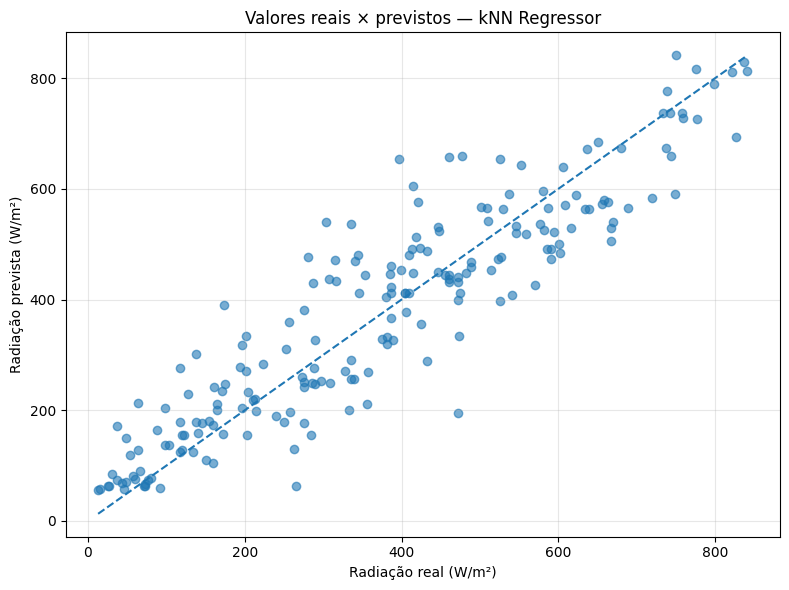

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_teste_regressao,
    melhores_previsoes_regressao,
    alpha=0.6
)

menor_valor = min(
    y_teste_regressao.min(),
    melhores_previsoes_regressao.min()
)

maior_valor = max(
    y_teste_regressao.max(),
    melhores_previsoes_regressao.max()
)

plt.plot(
    [menor_valor, maior_valor],
    [menor_valor, maior_valor],
    linestyle="--"
)

plt.title(
    f"Valores reais × previstos — {melhor_modelo_regressao}"
)

plt.xlabel("Radiação real (W/m²)")
plt.ylabel("Radiação prevista (W/m²)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Quanto mais próximos os pontos estiverem da linha diagonal, mais próximas as previsões estão dos valores reais.


## 13. Radiação real e prevista ao longo do tempo


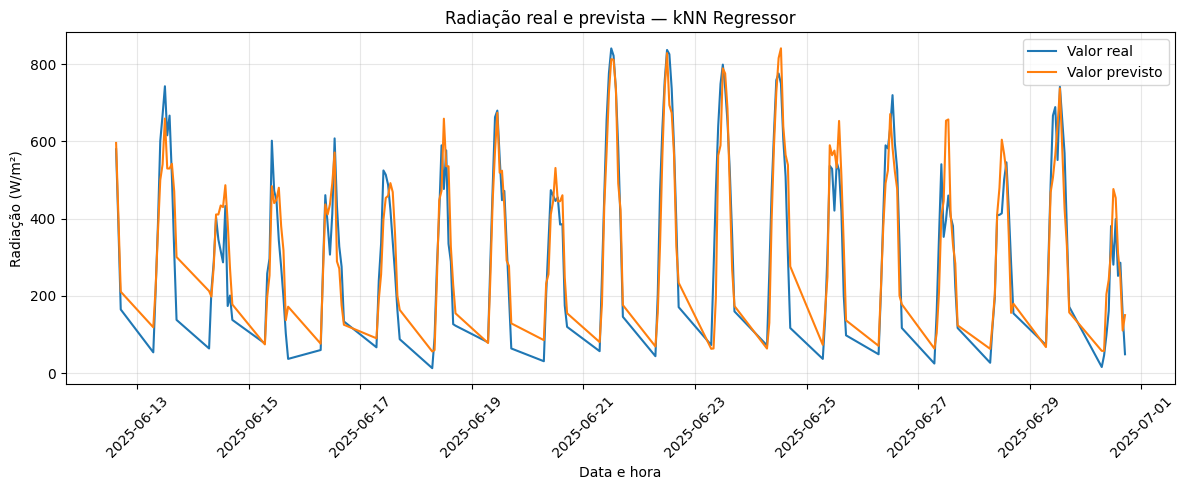

In [68]:
plt.figure(figsize=(12, 5))

plt.plot(
    datas_teste.values,
    y_teste_regressao.values,
    label="Valor real"
)

plt.plot(
    datas_teste.values,
    melhores_previsoes_regressao,
    label="Valor previsto"
)

plt.title(
    f"Radiação real e prevista — {melhor_modelo_regressao}"
)

plt.xlabel("Data e hora")
plt.ylabel("Radiação (W/m²)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Análise dos erros


In [69]:
erros = (
    y_teste_regressao.to_numpy()
    - np.asarray(melhores_previsoes_regressao)
)

print(
    "Erro médio:",
    round(erros.mean(), 2),
    "W/m²"
)

print(
    "Erro absoluto médio:",
    round(np.abs(erros).mean(), 2),
    "W/m²"
)

print(
    "Maior erro absoluto:",
    round(np.abs(erros).max(), 2),
    "W/m²"
)


Erro médio: -5.1 W/m²
Erro absoluto médio: 68.27 W/m²
Maior erro absoluto: 277.2 W/m²


### Conclusão — Regressão

Foram comparados **Regressão Linear, kNN Regressor e Árvore de Decisão**, todos utilizando a mesma divisão temporal.

As primeiras 80% das observações foram utilizadas para treinamento e as 20% finais para teste, preservando a ordem cronológica.

A variável `hora` possui importância porque a quantidade de radiação solar muda naturalmente ao longo do dia. Outras condições meteorológicas, como cobertura de nuvens, também podem influenciar o valor observado.

É importante destacar que estimar radiação solar **não equivale a prever diretamente a geração elétrica de um sistema fotovoltaico**.

A produção de energia depende de fatores adicionais, como potência instalada, eficiência dos módulos, inclinação, orientação, temperatura dos equipamentos, inversores e perdas elétricas. Portanto, o alvo deste modelo é a radiação solar disponível, e não a energia elétrica efetivamente produzida.


# Conclusão geral

Nesta atividade foram desenvolvidas duas tarefas de aprendizado de máquina relacionadas a energias renováveis.

Na classificação, o objetivo foi identificar a fonte de um empreendimento da ANEEL como **Solar, Eólica ou Hidráulica** utilizando potência e localização geográfica. Foram comparados Regressão Logística, kNN e Árvore de Decisão.

Na regressão, o objetivo foi estimar a radiação solar em Petrolina (PE) utilizando condições meteorológicas e a hora do dia. Foram comparados Regressão Linear, kNN Regressor e Árvore de Decisão.

A atividade também mostrou que a forma de separar os dados depende do problema. Na classificação foi utilizada divisão estratificada, enquanto na regressão a ordem temporal foi preservada.

As tabelas de resultados e os gráficos gerados durante a execução permitem comparar os seis modelos utilizando as métricas exigidas no enunciado.


## Exportação das tabelas de resultados

As tabelas comparativas serão salvas em CSV para facilitar a inclusão dos resultados no repositório.


In [70]:
resultado_classificacao_df.to_csv(
    "resultados_classificacao.csv",
    index=False,
    encoding="utf-8-sig"
)

resultado_regressao_df.to_csv(
    "resultados_regressao.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos salvos:")
print("- resultados_classificacao.csv")
print("- resultados_regressao.csv")


Arquivos salvos:
- resultados_classificacao.csv
- resultados_regressao.csv
